***Procesamiento avanzado de datos***

**José Roberto Torres López**


*Importacion de librerias, preparacion de los sets y división de los datos*

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Cargar y preparar datos numéricos básicos
df = pd.read_csv("../train.csv")
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[features].copy()
X['Sex'] = X['Sex'].map({'male': 0, 'female': 1}) # Texto a número
y = df['Survived']

# 2. División 70% Train, 15% Validación, 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Datos divididos -> Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Datos divididos -> Train: 623 | Val: 134 | Test: 134


*Imputación con KNNimputer y escalado con StandardScaley y MinMaxScaler*

In [58]:
# 1. Imputación con KNN (Rellenar edades faltantes)
imputador = KNNImputer(n_neighbors=5)

# fit_transform SOLO en train. En val y test SOLO transform.
X_train_imp = pd.DataFrame(imputador.fit_transform(X_train), columns=X_train.columns)
X_val_imp   = pd.DataFrame(imputador.transform(X_val), columns=X_val.columns)
X_test_imp  = pd.DataFrame(imputador.transform(X_test), columns=X_test.columns)

# 2. Escalado
columnas_a_escalar = ['Age', 'Fare', 'SibSp']

# --- StandardScaler ---
scaler_std = StandardScaler()
X_train_std = X_train_imp.copy()
X_val_std   = X_val_imp.copy()
X_test_std  = X_test_imp.copy()

X_train_std[columnas_a_escalar] = scaler_std.fit_transform(X_train_imp[columnas_a_escalar])
X_val_std[columnas_a_escalar]   = scaler_std.transform(X_val_imp[columnas_a_escalar])
X_test_std[columnas_a_escalar]  = scaler_std.transform(X_test_imp[columnas_a_escalar])

# --- MinMaxScaler ---
scaler_mm = MinMaxScaler()
X_train_mm = X_train_imp.copy()
X_val_mm   = X_val_imp.copy()
X_test_mm  = X_test_imp.copy()

X_train_mm[columnas_a_escalar] = scaler_mm.fit_transform(X_train_imp[columnas_a_escalar])
X_val_mm[columnas_a_escalar]   = scaler_mm.transform(X_val_imp[columnas_a_escalar])
X_test_mm[columnas_a_escalar]  = scaler_mm.transform(X_test_imp[columnas_a_escalar])

print("Datos imputados y escalados correctamente.")

Datos imputados y escalados correctamente.


*Visualización de los datos escalados en comparación a los sin escalar*

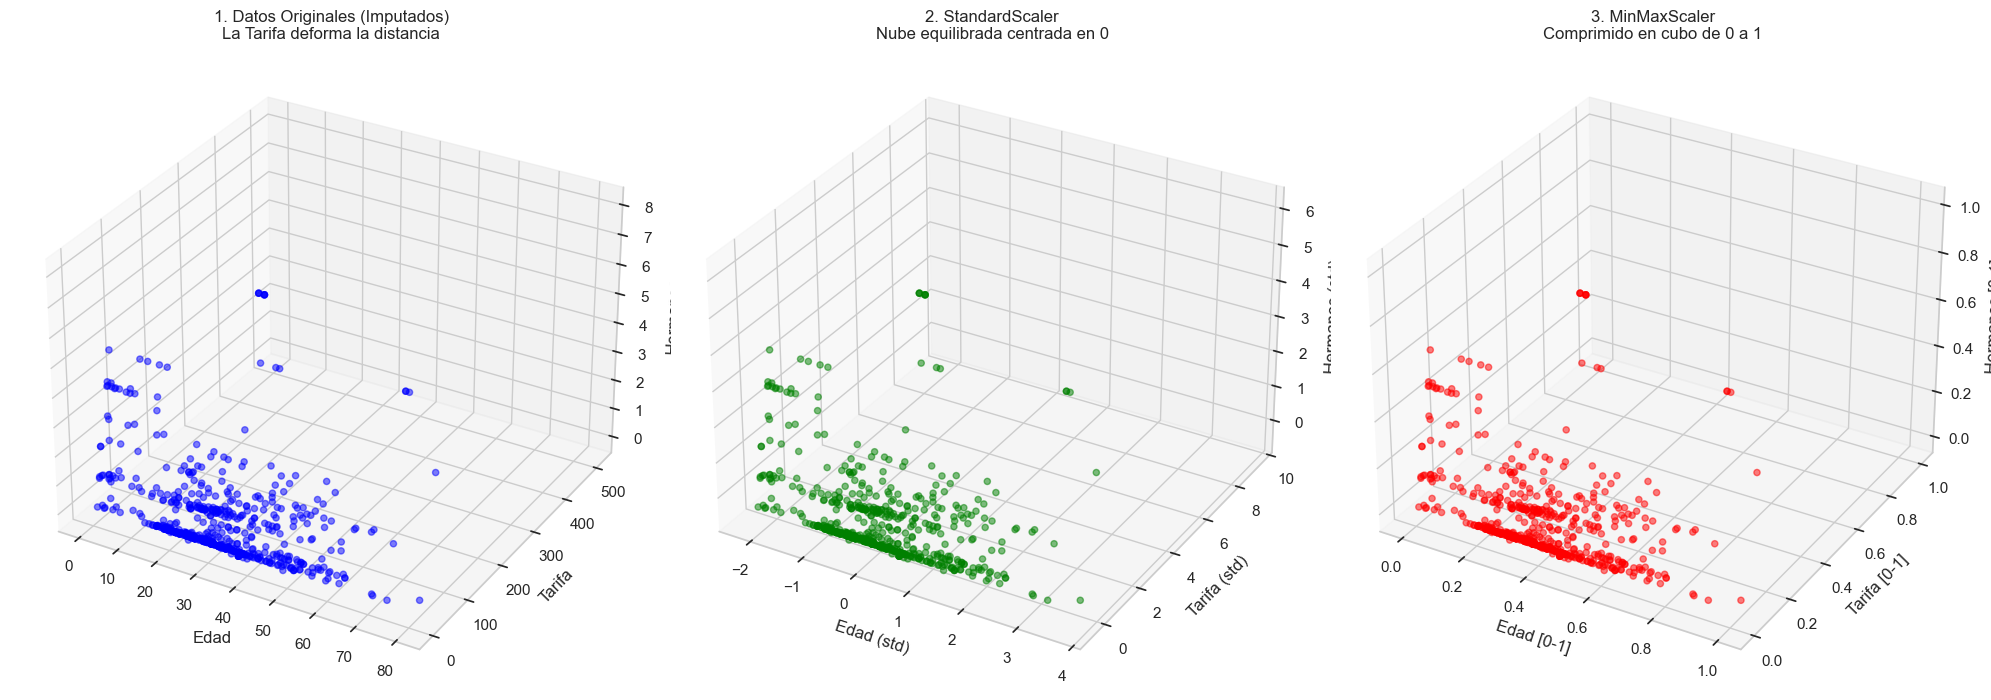

In [59]:
fig = plt.figure(figsize=(20, 7))

# 1. Datos Originales (Solo imputados)
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax1.scatter(X_train_imp['Age'], X_train_imp['Fare'], X_train_imp['SibSp'], c='blue', alpha=0.5)
ax1.set_title("1. Datos Originales (Imputados)\nLa Tarifa deforma la distancia")
ax1.set_xlabel("Edad"); ax1.set_ylabel("Tarifa"); ax1.set_zlabel("Hermanos")

# 2. StandardScaler
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax2.scatter(X_train_std['Age'], X_train_std['Fare'], X_train_std['SibSp'], c='green', alpha=0.5)
ax2.set_title("2. StandardScaler\nNube equilibrada centrada en 0")
ax2.set_xlabel("Edad (std)"); ax2.set_ylabel("Tarifa (std)"); ax2.set_zlabel("Hermanos (std)")

# 3. MinMaxScaler
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
ax3.scatter(X_train_mm['Age'], X_train_mm['Fare'], X_train_mm['SibSp'], c='red', alpha=0.5)
ax3.set_title("3. MinMaxScaler\nComprimido en cubo de 0 a 1")
ax3.set_xlabel("Edad [0-1]"); ax3.set_ylabel("Tarifa [0-1]"); ax3.set_zlabel("Hermanos [0-1]")

plt.tight_layout()
plt.show()

*Creación de los modelos junto a la evaluación inicial de cada uno*

In [60]:
def evaluar(modelo, X_t, y_t, X_v, y_v, nombre):
    modelo.fit(X_t, y_t)
    predicciones = modelo.predict(X_v)
    acc = accuracy_score(y_v, predicciones)
    print(f"{nombre}: {acc * 100:.2f}%")

arbol = DecisionTreeClassifier(random_state=42, max_depth=5) # max_depth evita que el árbol memorice
knn = KNeighborsClassifier(n_neighbors=5)

print("--- ÁRBOL DE DECISIÓN (Validación) ---")
evaluar(arbol, X_train_imp, y_train, X_val_imp, y_val, "Sin Escalar")
evaluar(arbol, X_train_std, y_train, X_val_std, y_val, "StandardScaler")
evaluar(arbol, X_train_mm, y_train, X_val_mm, y_val, "MinMaxScaler")

print("\n--- KNN (Validación) ---")
evaluar(knn, X_train_imp, y_train, X_val_imp, y_val, "Sin Escalar")
evaluar(knn, X_train_std, y_train, X_val_std, y_val, "StandardScaler")
evaluar(knn, X_train_mm, y_train, X_val_mm, y_val, "MinMaxScaler")

--- ÁRBOL DE DECISIÓN (Validación) ---
Sin Escalar: 82.84%
StandardScaler: 83.58%
MinMaxScaler: 82.84%

--- KNN (Validación) ---
Sin Escalar: 68.66%
StandardScaler: 79.10%
MinMaxScaler: 77.61%


*Prueba final con el test y con la matriz de confusión*

PRECISIÓN FINAL EN EL EXAMEN (Test): 79.10%



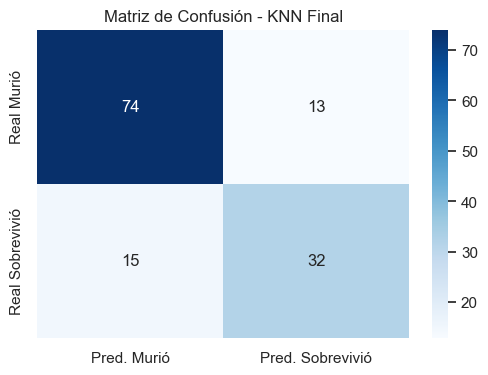

In [61]:
# Entrenamos el modelo definitivo con los datos de entrenamiento escalados
modelo_final = KNeighborsClassifier(n_neighbors=5)
modelo_final.fit(X_train_std, y_train)

# Predecimos sobre el set de PRUEBA (Test)
predicciones_test = modelo_final.predict(X_test_std)
precision_final = accuracy_score(y_test, predicciones_test)

print(f"PRECISIÓN FINAL EN EL EXAMEN (Test): {precision_final * 100:.2f}%\n")

# --- Matriz de Confusión ---
matriz = confusion_matrix(y_test, predicciones_test)

plt.figure(figsize=(6, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred. Murió', 'Pred. Sobrevivió'], 
            yticklabels=['Real Murió', 'Real Sobrevivió'])
plt.title('Matriz de Confusión - KNN Final')
plt.show()

*Visualizacion de los datos en 3*

**Conclusiónes personales**

Este cuaderno esta hecho a base de kNNimputer, el original se uso medidas de tendencia central para llenar los datos vacios. Ironicamente, el hecho de usar KNN para llenar los vacios resulto bajar la eficiencia de los modelos en un 2% a 3%, lo cual se justifica añadiendo mas realismo a los datos, pues es bien sabido que usar medidas de tendencia central suele ser perjudicial a veces añadiendo algo de irrealismo a los modelos. 

A comparacion del primer script, este es un poco mas optimizado y con menos celdas, pero considero que si es un poco mas complejo de usar, ya que existe el riesgo del data leakage provocando errores fatales en el modelado. Es buena opcion usar KNNimputer solamente si sabes que estas haciendo y si es algo mas serio para realizar.